Parameters

In [26]:
import re
import sys
from glob import glob
from pathlib import Path

import numpy as np
import h5py
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

# --- Directory containing lfads_output_*.h5 (written by run_posterior_sampling at the
#     end of 2_run_pbt_kcEXP00H.py, inside the run's best_model/ folder). ---
# Leave as None to auto-pick the most recent run; or set explicitly to a best_model dir.
H5_DIR = None
if H5_DIR is None:
    # cands = sorted(Path('../runs').glob(
        # 'kcEXP00H_multisession_202606291751/pbt/*/*/best_model'))
    cands = sorted(Path('../runs').glob(
        'kcEXP00H_multisession_202607161710/pbt/*/*/best_model'))
    cands = [c for c in cands if list(c.glob('lfads_output_*.h5'))]
    assert cands, "No best_model with lfads_output_*.h5 found under ../runs"
    H5_DIR = cands[-1]
H5_DIR = Path(H5_DIR)
print("Using LFADS outputs from:", H5_DIR)

# --- Source xarray (.nc) files: needed only for per-trial condition labels (PSTHs / colors) ---
XARRAY_DIR = (
    '../datasets/xarray_files/'
)

# The 8 stimulus conditions (V=vision, O=odor, F=forward-walk; x = off).
COND_ORDER = ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']

Using LFADS outputs from: ..\runs\kcEXP00H_multisession_202607161710\pbt\kcEXP00H_multisession_KC1pt2\260716\best_model


## Load lfads outputs

In [16]:
def merge_train_valid(train_data, valid_data, train_inds, valid_inds):
    n_samples = len(train_data) + len(valid_data)
    merged = np.full((n_samples, *train_data.shape[1:]), np.nan, dtype=train_data.dtype)
    merged[train_inds] = train_data
    merged[valid_inds] = valid_data
    return merged

h5_paths = sorted(glob(str(H5_DIR / 'lfads_output_*.h5')))
assert h5_paths, f"No lfads_output_*.h5 in {H5_DIR}"

factors = {}
predicted_ts = {} #analogous to rates in tutorial


### claude gen below
flies = []                # h5 stems, one per fly
train_inds, valid_inds = {},{}
observed_ts, predicted_ts, factors = {}, {}, {}     # merged (n_trials, n_frames_per_trial, .) in original trial order
split = {}                # 'train'/'valid' arrays for the held-out R^2 metric
for path in h5_paths:
    fly = Path(path).stem.replace('lfads_output_lfads_', '')
    flies.append(fly)
    with h5py.File(path) as f:
        train_inds[fly] = f['train_inds'][()].astype(int) #training trial indices 
        valid_inds[fly] = f['valid_inds'][()].astype(int) #validation trial indices
        observed_ts[fly]   = merge_train_valid(f['train_recon_data'][()],
                                         f['valid_recon_data'][()],train_inds[fly], valid_inds[fly] )
        predicted_ts[fly]    = merge_train_valid(f['train_output_params'][()],
                                         f['valid_output_params'][()], train_inds[fly], valid_inds[fly] )
        factors[fly] = merge_train_valid(f['train_factors'][()],
                                         f['valid_factors'][()], train_inds[fly], valid_inds[fly] )
        # split[fly] = dict(
        #     train=(observed_ts[trf['train_recon_data'][()], f['train_output_params'][()]),
        #     valid=(f['valid_recon_data'][()], f['valid_output_params'][()]),
        # )
    print(f"  {fly}: observed_ts/pred {observed_ts[fly].shape}, factors {factors[fly].shape}")

n_fac = next(iter(factors.values())).shape[-1]
n_frames_per_trial = next(iter(factors.values())).shape[1]
print(f"\n{len(flies)} flies | n_factors = {n_fac} | n_frames_per_trial = {n_frames_per_trial}")

  H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)
  H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)
  H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)
  H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 66), factors (16, 1050, 50)
  H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)

5 flies | n_factors = 50 | n_frames_per_trial = 1050


#### understand variables

In [3]:
path=h5_paths[0]

In [4]:
fly = Path(path).stem.replace('lfads_output_', '')
fly

'lfads_H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP'

In [5]:
f=h5py.File(path)

In [6]:
f1=f['train_output_params'][()]
f1.shape

(12, 1050, 67)

In [7]:
f2=f['train_recon_data'][()]
f2.shape

(12, 1050, 67)

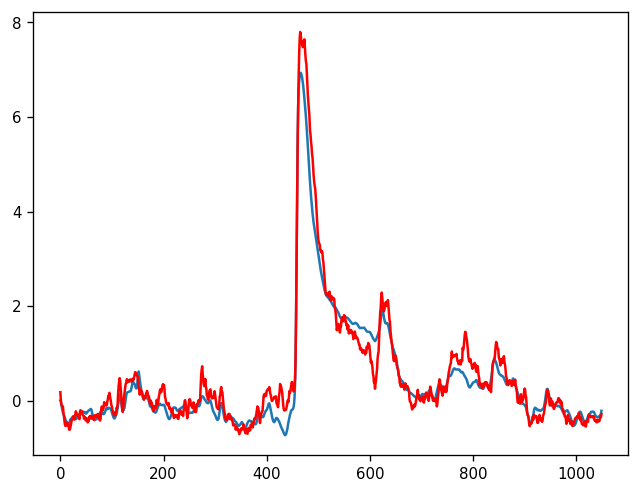

In [8]:
import matplotlib.pyplot as plt
plt.plot(f1[0,:,3]) 
plt.plot(f2[0,:,3],'r')
plt.show()

In [9]:
f.keys()

<KeysViewHDF5 ['readin_weight', 'readout_bias', 'train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_inds', 'train_output_params', 'train_recon_data', 'valid_co_means', 'valid_co_stds', 'valid_con_states', 'valid_encod_data', 'valid_factors', 'valid_gen_init', 'valid_gen_inputs', 'valid_gen_states', 'valid_ic_mean', 'valid_ic_std', 'valid_inds', 'valid_output_params', 'valid_recon_data', 'zscore_mean', 'zscore_std']>

In [10]:
f['readin_weight']

<HDF5 dataset "readin_weight": shape (67, 50), type "<f4">

In [11]:
type(split)

dict

In [12]:
# # split['lfads_H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP']
# # split[split.keys()[0]] <- doesn't work
# split[list(split.keys())[0]] #<- adding list works

## remove baseline trials

In [29]:
import xarray as xr

# condition labels keyed by .nc filename stem (e.g. 'H30003-005_..._DVAP')
cond_by_ncstem = {}
for p in sorted(glob(str(Path(XARRAY_DIR) / '*.nc'))):
    print(p)
    with xr.open_dataset(p) as ds:
        cond_by_ncstem[Path(p).stem] = \
            np.asarray(ds['condition'].values).reshape(-1).astype(str)


..\datasets\xarray_files\H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
..\datasets\xarray_files\H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
..\datasets\xarray_files\H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
..\datasets\xarray_files\H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
..\datasets\xarray_files\H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc


In [31]:
BASELINE_TRIALS=[0,9]
conditions = {}   # fly -> (n_trials,) str
for fly_name in flies:
    num_kept_trials = observed_ts[fly_name].shape[0]
    conditions_from_xarray = cond_by_ncstem[fly_name]
    if len(conditions_from_xarray) == num_kept_trials + len(BASELINE_TRIALS):
        conditions[fly_name] = np.delete(conditions_from_xarray, BASELINE_TRIALS)
    else:
        conditions[fly_name] = conditions_from_xarray


### 1. Model Performance
Train R^2 = how well model fit the training data

In [32]:
import pandas as pd

def r2(y, yhat):
    y = y.reshape(-1); yhat = yhat.reshape(-1)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1.0 - ss_res / ss_tot

In [35]:
r2train_flies={}
r2valid_flies={}
for fly in flies:
    obs= observed_ts[fly][train_inds[fly]]
    pred= predicted_ts[fly][train_inds[fly]]
    r2train_flies[fly] = r2(obs,pred)

    obs= observed_ts[fly][valid_inds[fly]]
    pred= predicted_ts[fly][valid_inds[fly]]
    r2valid_flies[fly] = r2(obs,pred)

# Compact fly labels for plotting (e.g. 'H30003-005')
def _short(fly):
    m = re.search(r'H\d+-\d+', fly)
    return m.group() if m else fly
short = {fly: _short(fly) for fly in flies}
short


{'H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP': 'H30003-005',
 'H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': 'H34006-007',
 'H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP': 'H35005-006',
 'H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': 'H36006-007',
 'H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP': 'H37003-004'}

In [36]:
r2_df

,fly,train,valid,fly_short
0,H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP,0.936587,0.780713,H30003-005
1,H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP,0.912953,0.803569,H34006-007
2,H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP,0.932372,0.789742,H35005-006
3,H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP,0.943156,0.846763,H36006-007
4,H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP,0.906524,0.816332,H37003-004


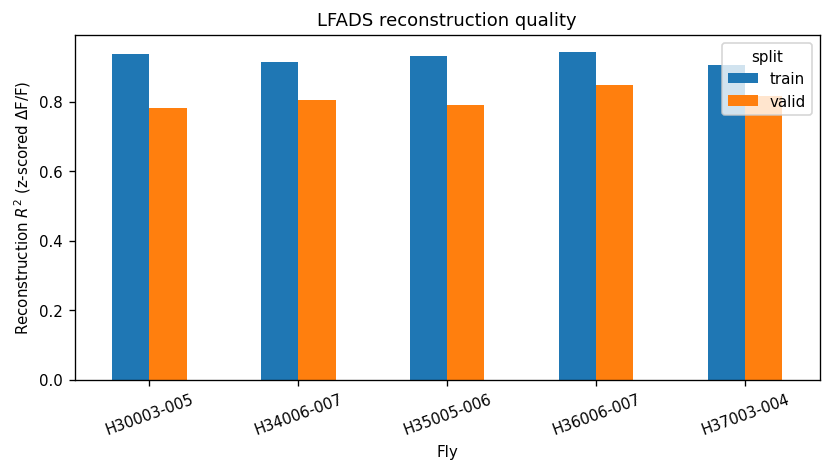

    fly_short  train  valid
0  H30003-005  0.937  0.781
1  H34006-007  0.913  0.804
2  H35005-006  0.932  0.790
3  H36006-007  0.943  0.847
4  H37003-004  0.907  0.816

Mean train R2 = 0.926 | mean valid R2 = 0.807


In [34]:
import pandas as pd
#create dataframe w/ train & valid as two columns then plot barplot

r2_df = (pd.DataFrame({'train': r2train_flies, 'valid': r2valid_flies})
        .rename_axis('fly').reset_index())
r2_df['fly_short'] = r2_df['fly'].map(short)

ax = r2_df.plot.bar(figsize=(7, 4), rot=20)
ax.set_xlabel('Fly'); ax.set_ylabel('Reconstruction $R^2$ (z-scored ΔF/F)')
ax.set_title('LFADS reconstruction quality')
ax.set_xticklabels(r2_df['fly_short'] )
ax.legend(title='split')
plt.tight_layout(); plt.show()

print(r2_df[["fly_short","train","valid"]].round(3))
print("\nMean train R2 = {:.3f} | mean valid R2 = {:.3f}".format(
    r2_df['train'].mean(), r2_df['valid'].mean()))



## 2-- visualize obs vs predicted TS

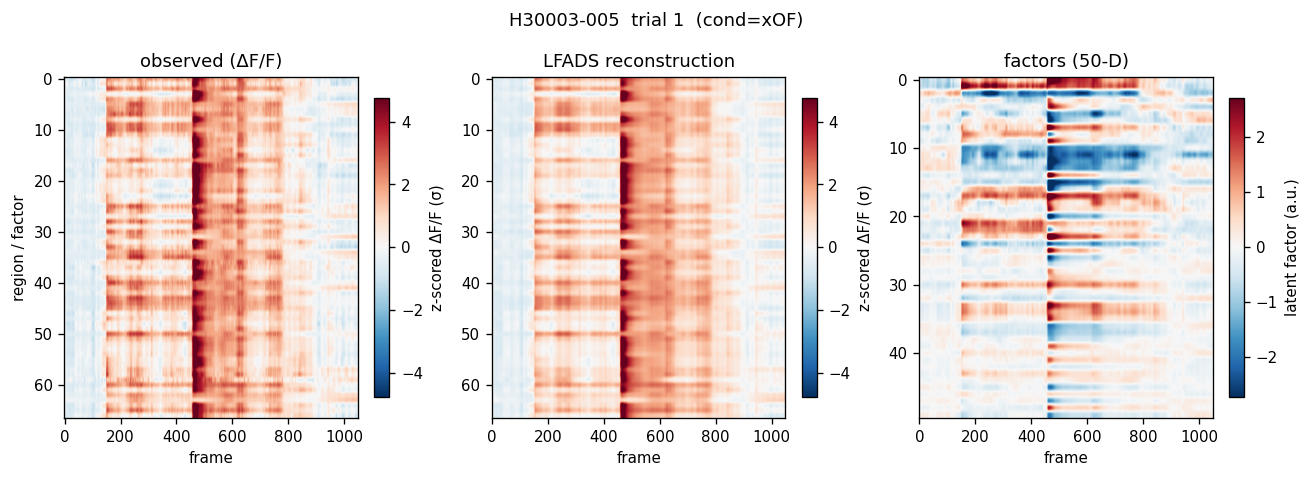

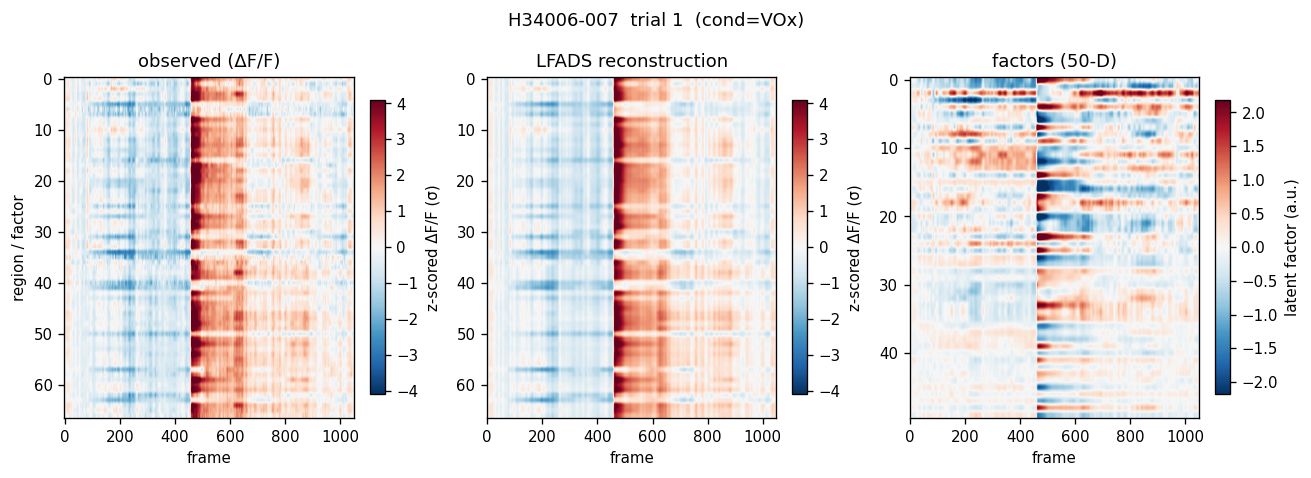

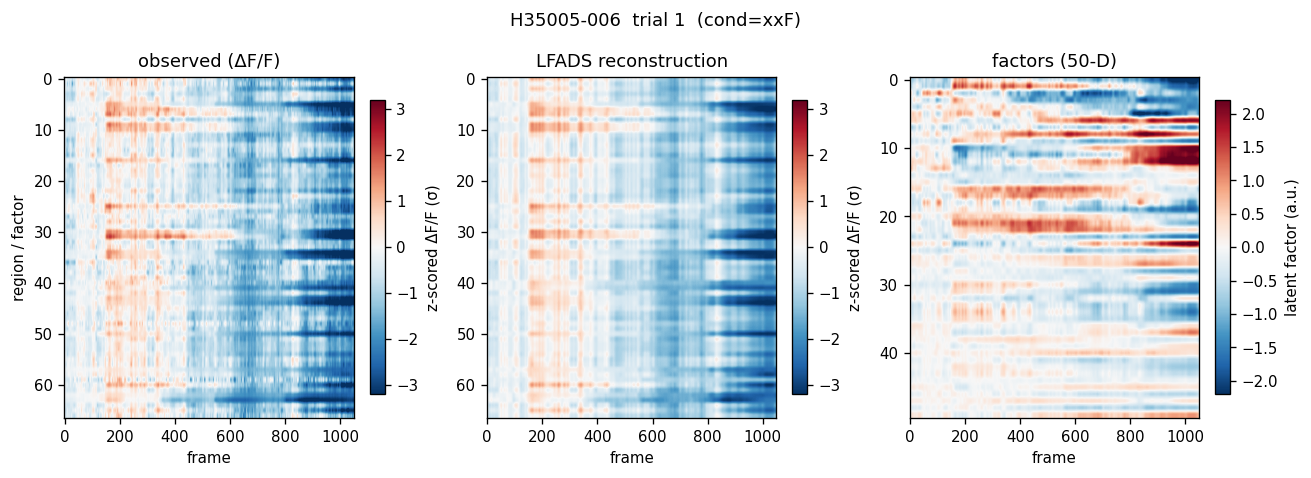

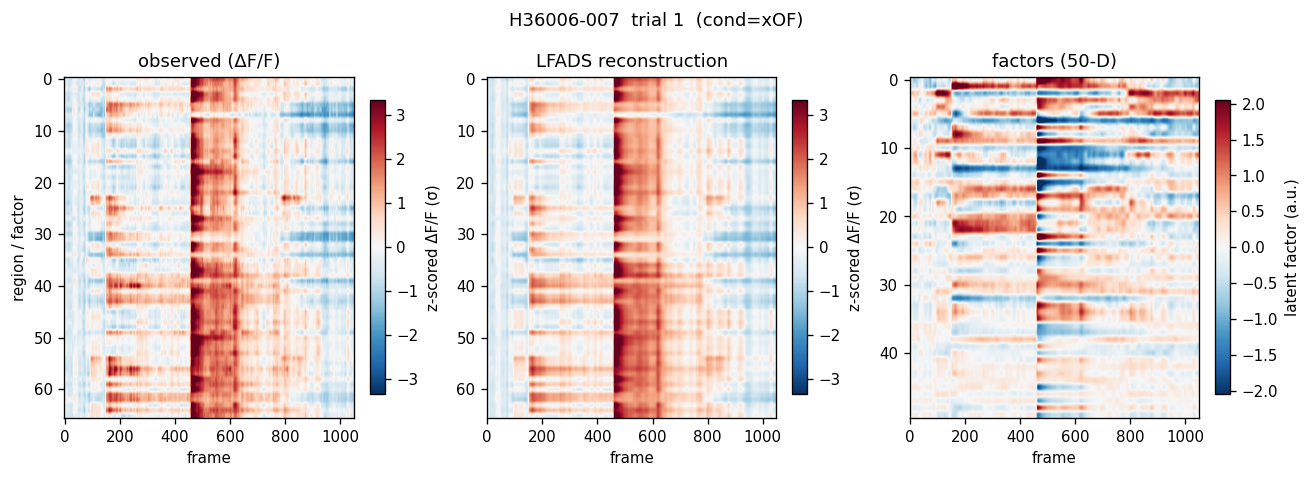

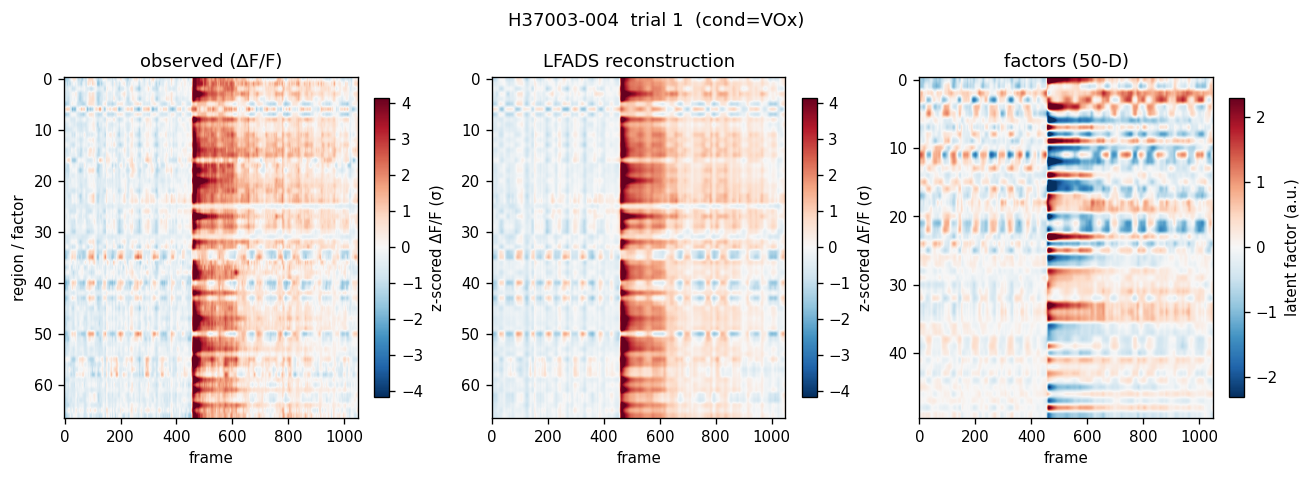

In [37]:
fly = flies[4]
trial = 1

for fly in flies:
    # (array, kind) — kind sets the colorbar range/label. observed & reconstruction share the
    # z-scored ΔF/F range; factors are unitless latent activations with their own range.
    panels = {
        'observed (ΔF/F)':       (observed_ts[fly][trial],   'dff'),
        'LFADS reconstruction':  (predicted_ts[fly][trial],    'dff'),
        f'factors ({n_fac}-D)':  (factors[fly][trial], 'fac'),
    }
    # shared symmetric range for the two ΔF/F panels; separate range for factors
    dff_vmax = np.nanpercentile(np.abs(np.concatenate([observed_ts[fly][trial], predicted_ts[fly][trial]])), 99)
    cbar_label = {'dff': 'z-scored ΔF/F (σ)', 'fac': 'latent factor (a.u.)'}

    fig, axes = plt.subplots(1, 3, figsize=(11, 4))
    for ax, (name, (arr, kind)) in zip(axes, panels.items()):
        vmax = dff_vmax if kind == 'dff' else np.nanpercentile(np.abs(arr), 99)
        im = ax.imshow(arr.T, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_title(name); ax.set_xlabel('frame')
        fig.colorbar(im, ax=ax, fraction=0.046, label=cbar_label[kind])
    axes[0].set_ylabel('region / factor')
    fig.suptitle(f'{short[fly]}  trial {trial}  (cond={conditions[fly][trial]})')
    plt.tight_layout(); plt.show()


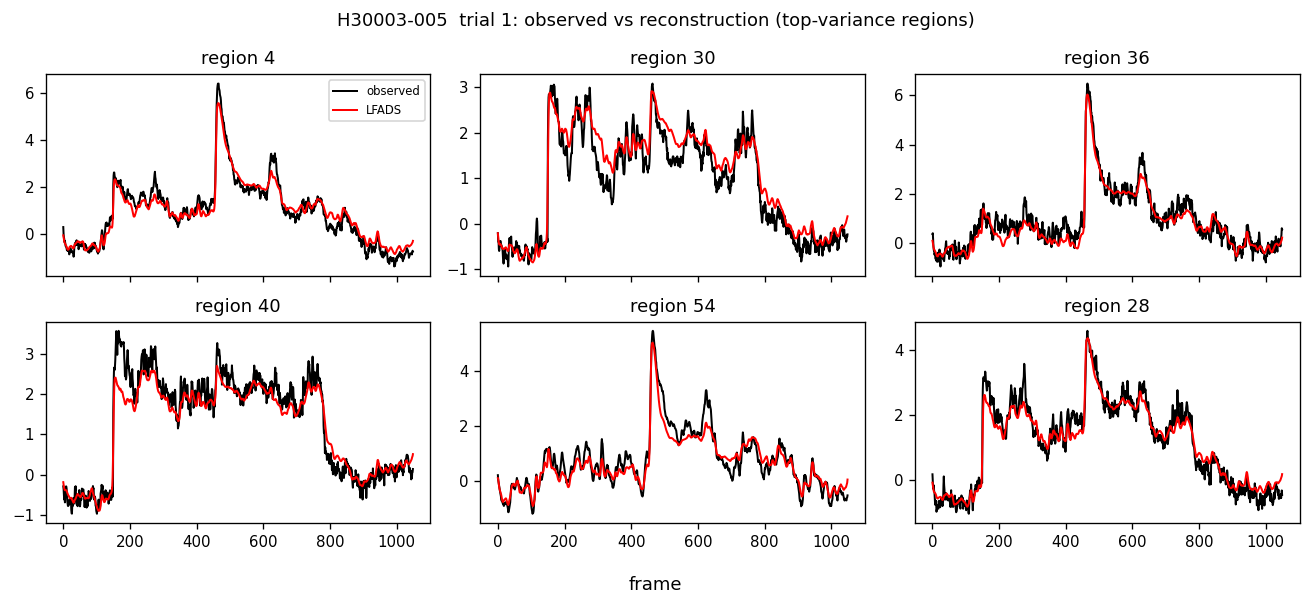

In [38]:
# Region-trace overlay: highest-variance regions for this fly
fly = flies[0]
trial=1
reg_var = observed_ts[fly].reshape(-1, observed_ts[fly].shape[-1]).var(0)
regs = np.argsort(reg_var)[::-1][:6]
fig, axes = plt.subplots(2, 3, figsize=(11, 5), sharex=True)
for ax, r in zip(axes.flatten(), regs):
    ax.plot(observed_ts[fly][trial, :, r], 'k', lw=1.2, label='observed')
    ax.plot(predicted_ts[fly][trial, :, r], 'r', lw=1.2, label='LFADS')
    ax.set_title(f'region {r}')
axes[0, 0].legend(fontsize=7)
fig.suptitle(f'{short[fly]}  trial {trial}: observed vs reconstruction (top-variance regions)')
fig.supxlabel('frame'); plt.tight_layout(); plt.show()

## 3.1 — Latent state-space

One PCA fit across **all flies' factors**, then per-fly 3-D trajectories colored by stimulus
condition (parallel to the Rouse tutorial's reach-direction trajectories). If the multisession
model found a **shared, fly-invariant** latent code, the per-fly subplots look alike and the same
condition occupies the same region of factor space across flies.

explained variance (PC1-3): [0.501 0.137 0.105]  sum = 0.743


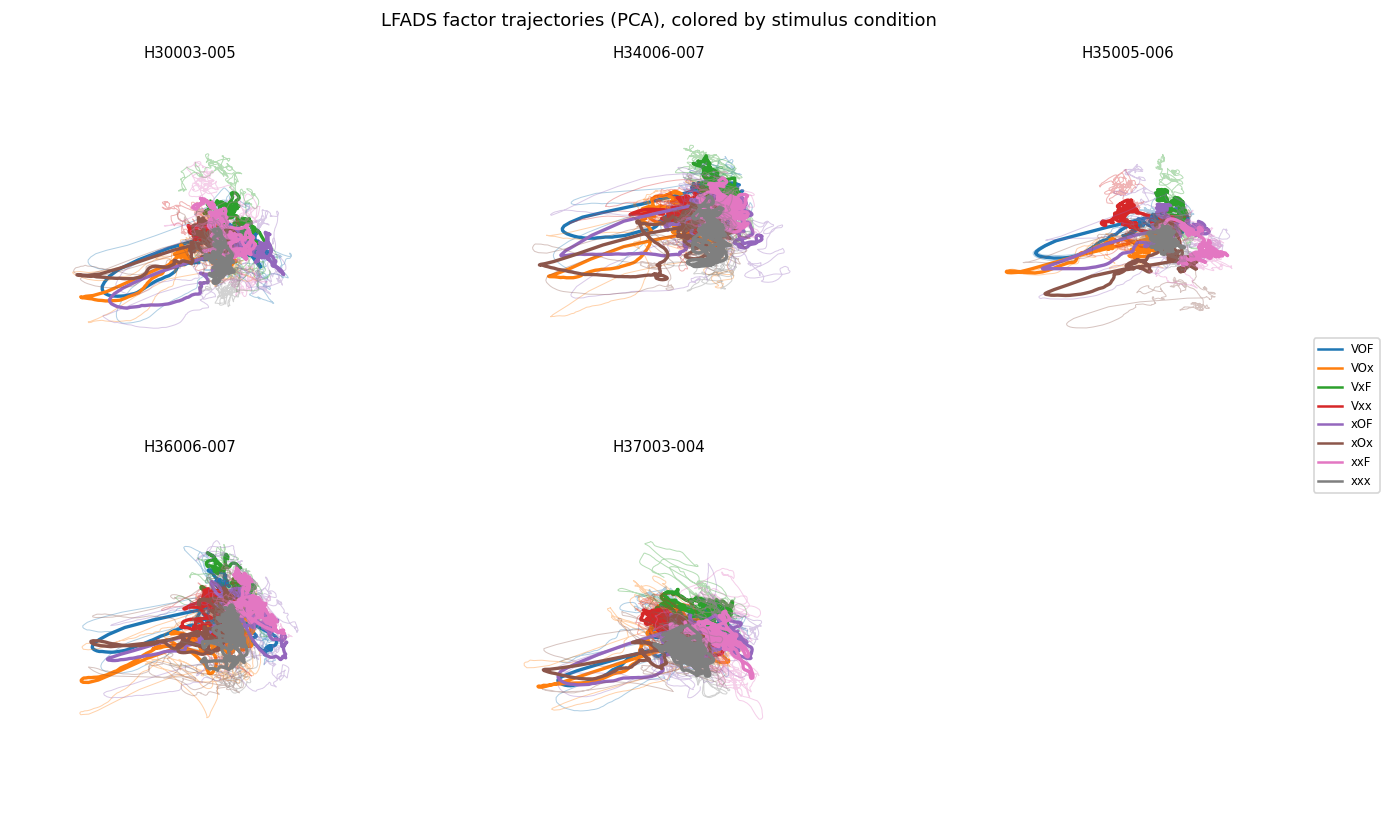

In [39]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib import cm
# The 8 stimulus conditions (V=vision, O=odor, F=forward-walk; x = off).
COND_ORDER = ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']

# Fit one PCA + scaler on all factors pooled across flies
all_fac = np.concatenate([factors[f].reshape(-1, n_fac) for f in flies], 0)
ss = StandardScaler().fit(all_fac)
pca = PCA(n_components=3).fit(ss.transform(all_fac))
print("explained variance (PC1-3):", np.round(pca.explained_variance_ratio_, 3),
      " sum =", round(pca.explained_variance_ratio_[:3].sum(), 3))

colors = {c: cm.tab10(i % 10) for i, c in enumerate(COND_ORDER)}
ncol = min(len(flies), 3)
nrow = int(np.ceil(len(flies) / ncol))
fig = plt.figure(figsize=(4 * ncol, 3.5 * nrow))
for i, fly in enumerate(flies):
    ax = fig.add_subplot(nrow, ncol, i + 1, projection='3d')
    f3 = pca.transform(ss.transform(factors[fly].reshape(-1, n_fac)))
    f3 = f3.reshape(factors[fly].shape[0], n_frames_per_trial, 3)
    conds = conditions[fly]
    for c in [c for c in COND_ORDER if (conds == c).any()]:
        for tr in np.where(conds == c)[0]:
            ax.plot(*f3[tr].T, color=colors[c], alpha=0.35, lw=0.6)
        ax.plot(*f3[conds == c].mean(0).T, color=colors[c], lw=2)
    ax.set_title(short[fly], fontsize=9); ax.axis('off')
    ax.view_init(elev=15., azim=37.5)
handles = [plt.Line2D([], [], color=colors[c], label=c)
           for c in COND_ORDER]
fig.legend(handles=handles, loc='center right', fontsize=7, ncol=1)
fig.suptitle('LFADS factor trajectories (PCA), colored by stimulus condition')
plt.tight_layout(); plt.show()

### 3.2 visualize latents

In [41]:
stim_colors = {'odor': 'tab:green', 'walk': 'tab:orange', 'vision': 'tab:purple'}
cond_cmap = {c: cm.tab10(i % 10) for i, c in enumerate(COND_ORDER)}
cond_cmap

{'VOF': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
 'VOx': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
 'VxF': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0),
 'Vxx': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0),
 'xOF': (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
 'xOx': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0),
 'xxF': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902, 1.0),
 'xxx': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745, 1.0)}

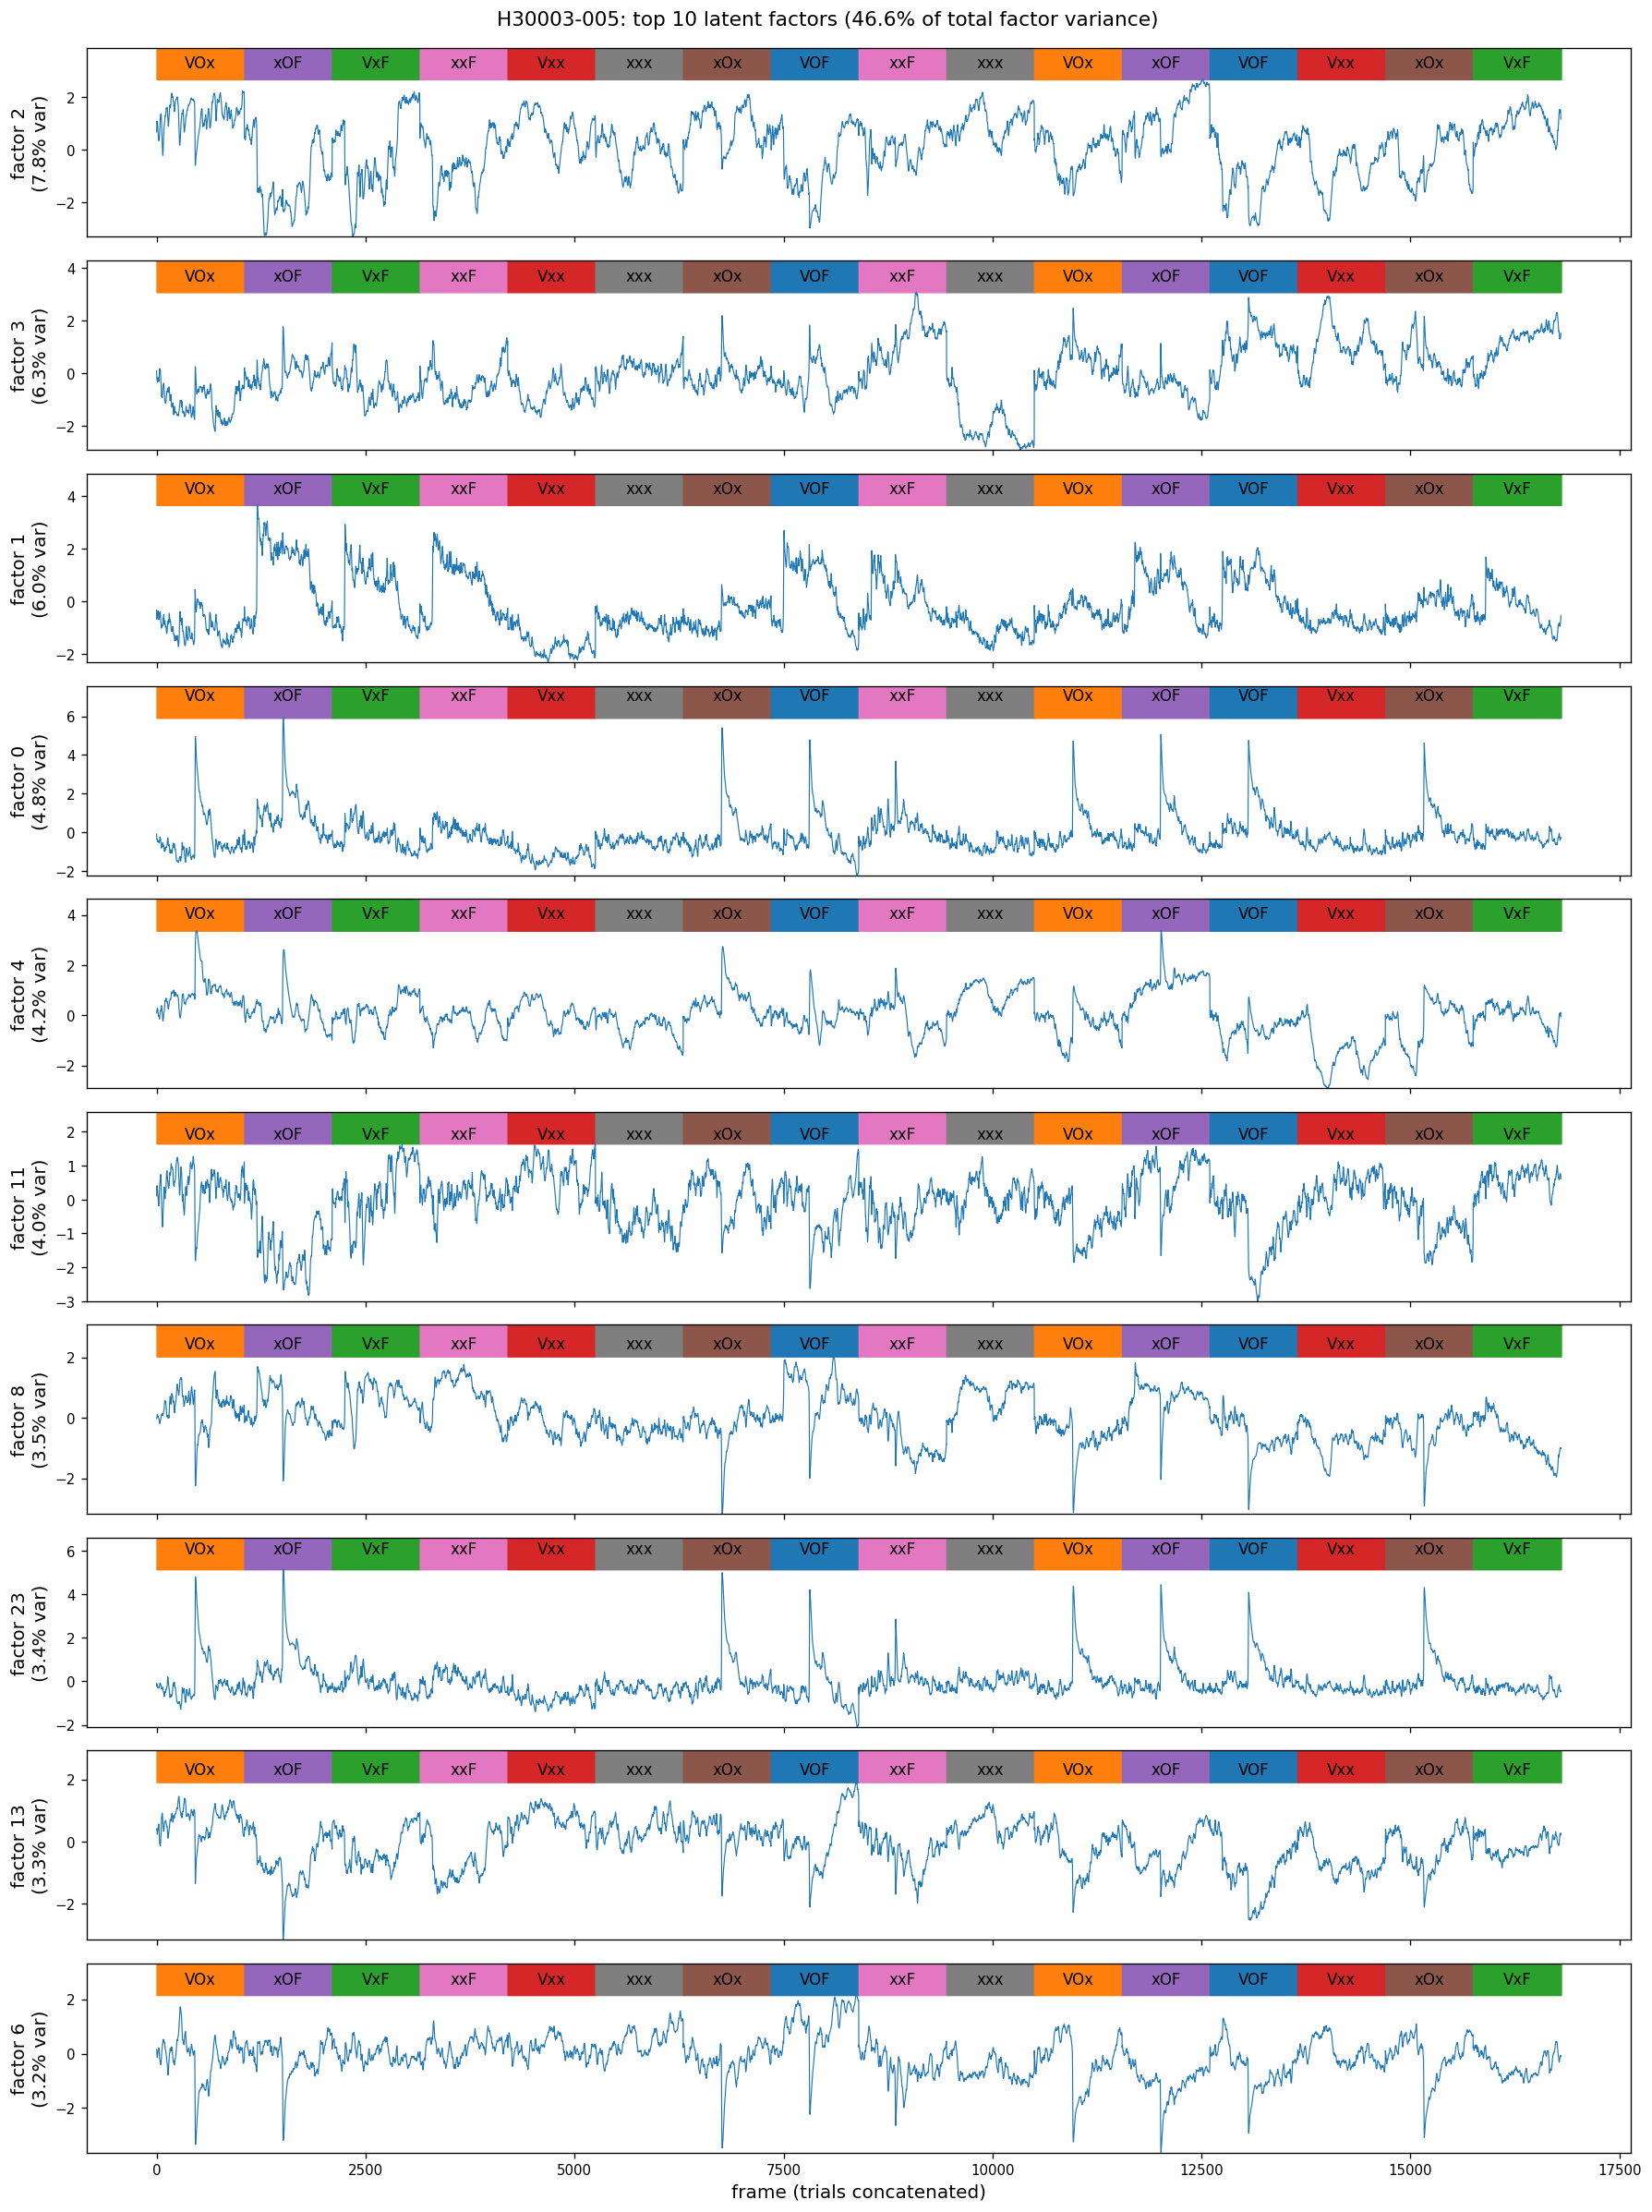

In [42]:
fly='H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP'
factor = factors[fly]

n_trials = conditions[fly].shape[0]
x = np.arange(n_trials*n_frames_per_trial)
smask = {i: (x >= i*n_frames_per_trial) & (x < (i+1)*n_frames_per_trial)
         for i in range(n_trials)}  # one boolean mask per trial for the condition color bars

n_show = 10
fac_var = factor.reshape(-1, n_fac).var(0) #collapses trials and frames into one axis numTrials*numFrames,50.var(0)
frac_var = fac_var / fac_var.sum()          # share of total factor variance
top_fac = np.argsort(fac_var)[::-1][:n_show]  # top 10 latents by variance

fig, axes = plt.subplots(n_show, 1, figsize=(15, 2*n_show), sharex=True)
for ax, i_fac in zip(axes, top_fac):
    flat_factor = factor[:,:,i_fac].flatten() #flatten all trials into one long expt for plotting
    ax.plot(flat_factor, lw=0.7)
    lo, hi = flat_factor.min(), flat_factor.max()
    ylim = [hi, hi + 0.2*(hi-lo)]  # color bar sits just above the trace
    for i_condition in range(len(conditions[fly])):
        condition = conditions[fly][i_condition]
        ax.fill_between(x, ylim[0], ylim[1], where=smask[i_condition], color=cond_cmap[condition])
    ax.set_ylim(lo, ylim[1])
    ax.set_ylabel(f'factor {i_fac}\n({100*frac_var[i_fac]:.1f}% var)',fontsize=12)
    for i_condition in range(len(conditions[fly])):
        ax.text((i_condition + 0.5) * n_frames_per_trial, ax.get_ylim()[1]-0.9,
                    conditions[fly][i_condition], ha='center', va='bottom',
                    fontsize=10, rotation=0) #adds condition text labels above the top subplot
# for i_condition in range(len(conditions[fly])):
#     axes[0].text((i_condition + 0.5) * n_frames_per_trial, axes[0].get_ylim()[1]-0.9,
#                  conditions[fly][i_condition], ha='center', va='bottom',
#                  fontsize=10, rotation=0) #adds condition text labels above the top subplot

axes[-1].set_xlabel('frame (trials concatenated)',fontsize=12)
fig.suptitle(f'{short[fly]}: top {n_show} latent factors '
             f'({100*frac_var[top_fac].sum():.1f}% of total factor variance)', y=0.995, fontsize=13)
plt.tight_layout(); plt.show()

In [43]:
# proof of principle for using a mask to plot the color bars for the different conditions
# smask = {}
# for i_condition, condition_name in enumerate(conditions[fly]):
#     # print(condition_name)
#     smask[i_condition] = np.zeros(len(flat_factor))
#     smask[i_condition][i_condition*n_frames_per_trial:(i_condition+1)*n_frames_per_trial] += 1

# plt.imshow(list(smask.values()),aspect='auto')

## load data xarrays


In [44]:
ds= xr.load_dataset(list(Path(XARRAY_DIR).glob('*.nc'))[0])

In [45]:
ds

<xarray.Dataset> Size: 23MB
Dimensions:           (time: 1050, region: 75, trial: 18)
Coordinates: (12/13)
  * time              (time) int32 4kB 0 1 2 3 4 5 ... 1045 1046 1047 1048 1049
    odor_state_frame  (time) float64 8kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    fw_state_frame    (time) float64 8kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    vis_state_frame   (time) float64 8kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
  * region            (region) object 600B 'AME-R' 'LO-R' ... 'EPA-L' 'GA-L'
    condition         (trial) object 144B 'xxx' 'VOx' 'xOF' ... 'xOx' 'VxF'
    ...                ...
    odor_trial_bool   (trial) bool 18B False True True ... False True False
    vis_trial_bool    (trial) bool 18B False True False True ... True False True
    fw_trial_bool     (trial) bool 18B False False True ... False False True
    n_recording       (trial) int32 72B 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1
    trial_within_rec  (trial) int32 72B 0 1 2 3 4 5 6 7 8 0 1 2 3 4 5 6 7 8
    is_baseline       (trial) bool 18B True False False ... False False False
Data variables:
    deltaF_rg         (trial, time, region) float64 11MB nan nan ... -0.004991
    trialTS_rg        (trial, time, region) float64 11MB nan nan ... -0.00637
Attributes:
    identifier:          H30003-005
    trials_per_rec:      9
    odor_scanstarts:     [ 600534. 1020531. 3120541. 3540538. 5220536. 564054...
    odor_scanends:       [ 660616. 1080613. 3180622. 3600619. 5280617. 570062...
    odor_trial_indices:  [ 2  3  8  9 13 14 15 17]
    fw_scanstarts:       [ 900014. 1320001. 1740001. 3420007. 4260001. 552000...
    fw_scanends:         [1152000. 1572001. 1991996. 3671996. 4512002. 577200...
    fw_trial_indices:    [ 3  4  5  9 11 14 15 18]
    vis_scanstarts:      [ 588056. 1428259. 2268072. 3528148. 5208097. 604826...
    vis_patt_scanon:     [ 540002. 1380002. 2220002. 3480002. 5160002. 600000...
    vis_patt_scanoff:    [ 684002. 1524002. 2364002. 3624002. 5304002. 614400...
    vis_trial_indices:   [ 2  4  6  9 13 15 16 18]

In [46]:
observed_ts

{'H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP': array([[[-0.7268904 , -0.6922432 , -0.7630103 , ..., -0.39707574,
          -0.96188366, -0.0842242 ],
         [-0.7910626 ,  0.15541863, -0.71688133, ..., -0.47974977,
          -0.9673029 , -0.21349508],
         [-0.77641153, -0.05711857, -0.5947398 , ..., -0.6141279 ,
          -1.0421939 , -0.3117813 ],
         ...,
         [-0.4589104 ,  0.5512923 , -0.9867415 , ..., -0.24234203,
          -0.7855007 , -0.23323256],
         [-0.66603065,  0.9368036 , -0.885835  , ..., -0.22807442,
          -0.90944004, -0.5145672 ],
         [-0.810988  ,  0.7044624 , -0.98987865, ..., -0.3569095 ,
          -0.77014714, -0.34819835]],
 
        [[ 0.129748  ,  0.426594  ,  0.07591358, ...,  0.17176194,
           0.07536024,  0.3791188 ],
         [-0.3755993 , -0.18293457, -0.10625798, ..., -0.0663587 ,
          -0.1964218 ,  0.4550317 ],
         [-0.6568319 , -0.17348106, -0.2685355 , ..., -0.20607853,
          -0.18282463, -0.034870

## factor correlation to stimuli features

smask

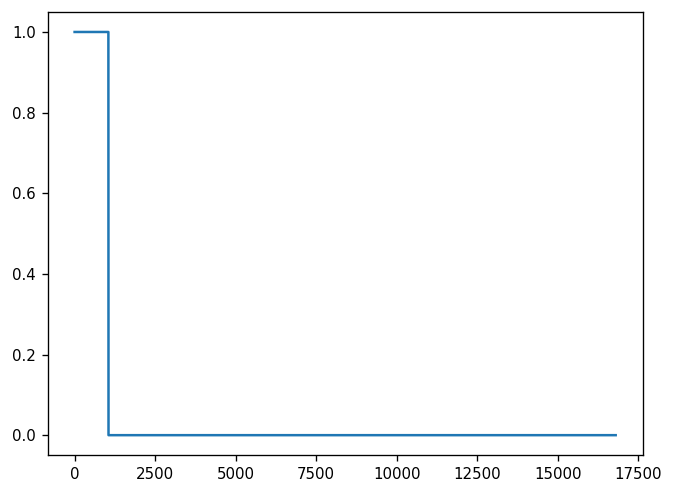

In [47]:
plt.plot(smask[0])
plt.show()

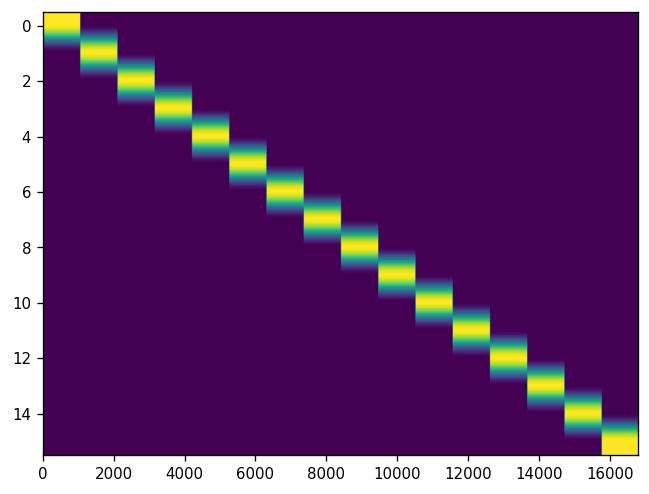

In [48]:
plt.imshow(list(smask.values()),aspect="auto")


In [49]:
cond_cmap

{'VOF': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
 'VOx': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
 'VxF': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0),
 'Vxx': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0),
 'xOF': (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
 'xOx': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0),
 'xxF': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902, 1.0),
 'xxx': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745, 1.0)}

In [50]:
smask[i_condition]

array([False, False, False, ...,  True,  True,  True])

In [51]:
ccc = 'VxF'

In [52]:
condition == ccc

True

In [53]:
conditions

{'H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP': array(['VOx', 'xOF', 'VxF', 'xxF', 'Vxx', 'xxx', 'xOx', 'VOF', 'xxF',
        'xxx', 'VOx', 'xOF', 'VOF', 'Vxx', 'xOx', 'VxF'], dtype='<U3'),
 'H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': array(['VOF', 'VOx', 'xOF', 'xxx', 'Vxx', 'VxF', 'xOx', 'xxF', 'xOx',
        'VOF', 'VxF', 'VOx', 'xxx', 'xxF', 'Vxx', 'xOF'], dtype='<U3'),
 'H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP': array(['xOF', 'xxF', 'Vxx', 'xOx', 'VOF', 'VxF', 'VOx', 'xxx', 'xxx',
        'VOx', 'VOF', 'xxF', 'xOx', 'Vxx', 'VxF', 'xOF'], dtype='<U3'),
 'H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': array(['VOx', 'xOF', 'Vxx', 'VOF', 'VxF', 'xOx', 'xxF', 'xxx', 'VOx',
        'xxF', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxx', 'VOF'], dtype='<U3'),
 'H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP': array(['Vxx', 'VOx', 'xOx', 'xxx', 'xxF', 'VOF', 'xOF', 'VxF', 'xxF',
        'xxx', 'xOx', 'VOF', 'VOx', 'Vxx', 'xOF', 'VxF'], dtype='<U3')}

In [54]:
condition_vector = dict()

for i_condition, condition in enumerate(conditions[fly]):
    print(i_condition, condition)
    condition_vector[condition] = np.zeros(16800)

for i, condition1 in enumerate(conditions[fly]):
    for condition2 in condition_vector.keys():
    #for i in range(n_trials):
        if condition1 == condition2:
            condition_vector[condition1] += (x >= i*n_frames_per_trial) & (x < (i+1)*n_frames_per_trial)

condition_vector

0 VOx
1 xOF
2 VxF
3 xxF
4 Vxx
5 xxx
6 xOx
7 VOF
8 xxF
9 xxx
10 VOx
11 xOF
12 VOF
13 Vxx
14 xOx
15 VxF


{'VOx': array([1., 1., 1., ..., 0., 0., 0.]),
 'xOF': array([0., 0., 0., ..., 0., 0., 0.]),
 'VxF': array([0., 0., 0., ..., 1., 1., 1.]),
 'xxF': array([0., 0., 0., ..., 0., 0., 0.]),
 'Vxx': array([0., 0., 0., ..., 0., 0., 0.]),
 'xxx': array([0., 0., 0., ..., 0., 0., 0.]),
 'xOx': array([0., 0., 0., ..., 0., 0., 0.]),
 'VOF': array([0., 0., 0., ..., 0., 0., 0.])}

In [55]:
(x >= i*n_frames_per_trial) & (x < (i+1)*n_frames_per_trial)

array([False, False, False, ...,  True,  True,  True])

([<matplotlib.axis.YTick at 0x22cc8296a30>,
 [Text(0, 0, 'VOx'),
  Text(0, 1, 'xOF'),
  Text(0, 2, 'VxF'),
  Text(0, 3, 'xxF'),
  Text(0, 4, 'Vxx'),
  Text(0, 5, 'xxx'),
  Text(0, 6, 'xOx'),
  Text(0, 7, 'VOF')])

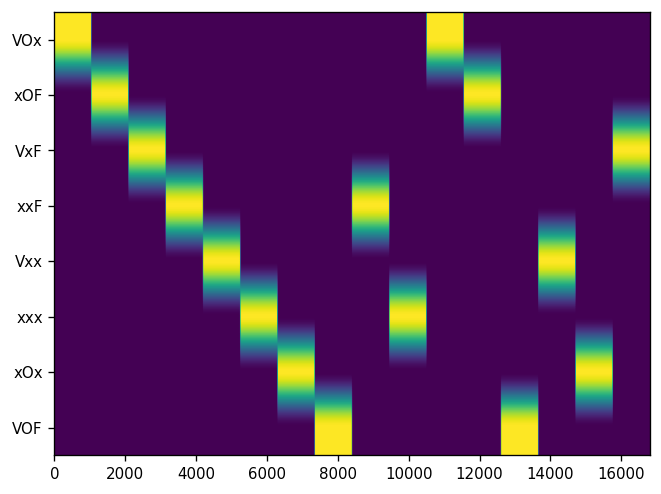

In [56]:
plt.imshow(list(condition_vector.values()), aspect='auto')
plt.yticks(np.arange(len(condition_vector)), list(condition_vector.keys()))

In [57]:
import scipy

In [58]:
pearson_r_p = dict()

for cond in condition_vector.keys():
    pearson_r_p[cond]= scipy.stats.pearsonr(condition_vector[cond],flat_factor)
    pearson_r_p

In [59]:
pearson_r_p

{'VOx': PearsonRResult(statistic=-0.04402352255300705, pvalue=1.1401399199178157e-08),
 'xOF': PearsonRResult(statistic=-0.2126503264253854, pvalue=4.660210676993089e-171),
 'VxF': PearsonRResult(statistic=-0.05087766161302326, pvalue=4.15951803176888e-11),
 'xxF': PearsonRResult(statistic=0.014365097367633972, pvalue=0.06261902816969313),
 'Vxx': PearsonRResult(statistic=0.12900595165484435, pvalue=2.8866024943816065e-63),
 'xxx': PearsonRResult(statistic=0.02399878790506436, pvalue=0.001865718060628751),
 'xOx': PearsonRResult(statistic=-0.03199303690632199, pvalue=3.3608936241717055e-05),
 'VOF': PearsonRResult(statistic=0.17217471057019473, pvalue=6.113259064267605e-112)}

In [173]:
1050*18

18900

In [177]:
len(ds['time'])

1050

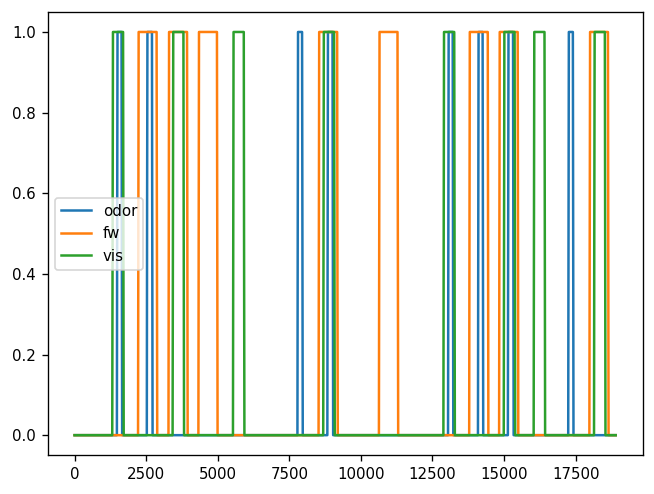

In [178]:
#convert ds[___state_frame] from 1050 frames to 16800 frames due to matlab export code error
complete_nframes = len(ds['trial'])*len(ds['time'])
odor_frames_flat = np.interp(np.linspace(0, len(ds['odor_state_frame'])-1, complete_nframes ),
                                         np.arange(len(ds['odor_state_frame'])),
                                                   ds['odor_state_frame'])

fw_frames_flat = np.interp(np.linspace(0, len(ds['fw_state_frame'])-1, complete_nframes ),
                                         np.arange(len(ds['fw_state_frame'])),
                                                   ds['fw_state_frame'])

vis_frames_flat = np.interp(np.linspace(0, len(ds['vis_state_frame'])-1, complete_nframes ),
                                         np.arange(len(ds['vis_state_frame'])),
                                                   ds['vis_state_frame'])


plt.plot(odor_frames_flat, label='odor')
plt.plot(fw_frames_flat, label='fw')
plt.plot(vis_frames_flat, label='vis')
plt.legend()
plt.show()

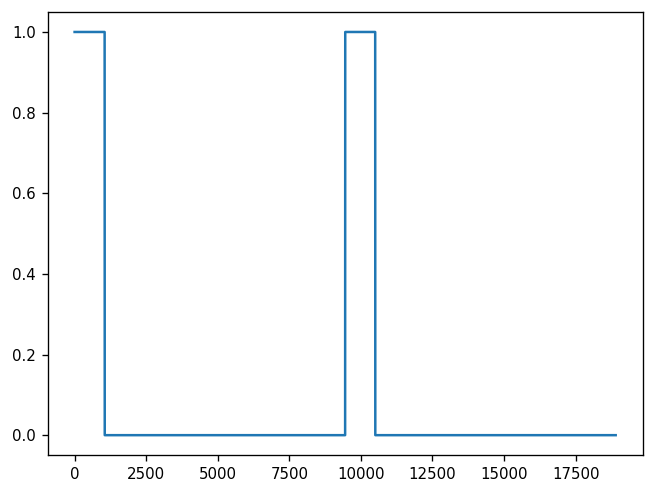

In [196]:
temp_var = np.arange(len(odor_frames_flat))
mask = np.zeros(len(temp_var))
for i in range(len(BASELINE_TRIALS)):
    mask += np.logical_and(temp_var >= BASELINE_TRIALS[i]*len(ds['time']), \
                temp_var < (BASELINE_TRIALS[i]+1)*len(ds['time']))

plt.plot(mask)

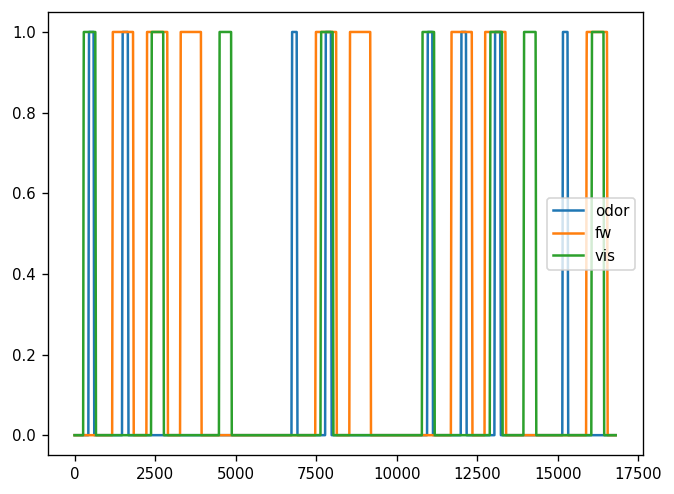

In [199]:
odor_frames_flat = odor_frames_flat[~mask.astype(bool)]
fw_frames_flat = fw_frames_flat[~mask.astype(bool)]
vis_frames_flat = vis_frames_flat[~mask.astype(bool)]
plt.plot(odor_frames_flat, label='odor')
plt.plot(fw_frames_flat, label='fw')
plt.plot(vis_frames_flat, label='vis')
plt.legend()
plt.show()

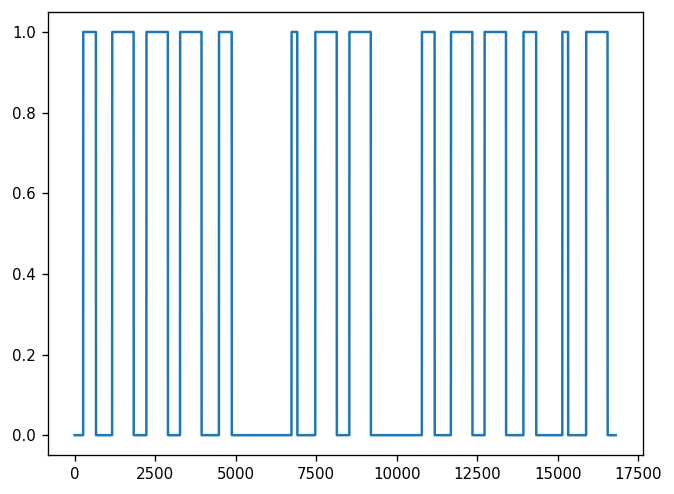

In [200]:
condition_frames = odor_frames_flat + vis_frames_flat + fw_frames_flat

condition_frames[condition_frames > 0] = 1

plt.plot(condition_frames)

In [201]:
condition_vector_bool = condition_vector

condition_vec_stim_only = dict()
for cond in condition_vector_bool:
    condition_vec_stim_only[cond] = condition_vector_bool[cond]*condition_frames

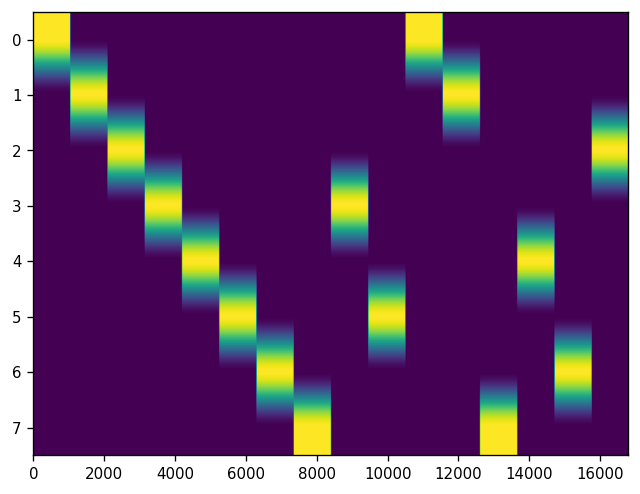

In [202]:
plt.imshow(list(condition_vector.values()), aspect='auto')

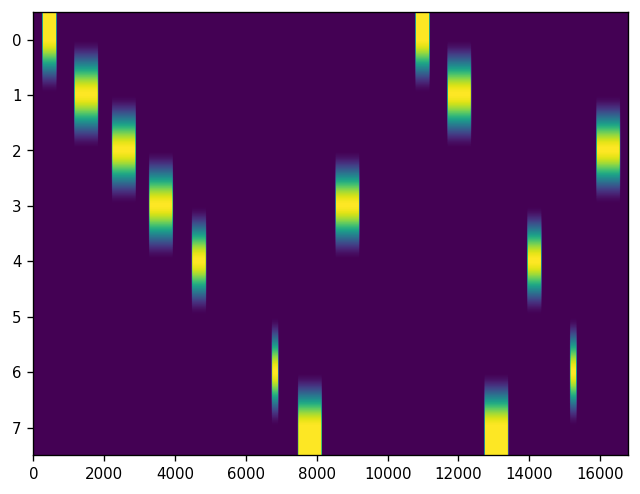

In [203]:
plt.imshow(list(condition_vec_stim_only.values()), aspect='auto')

In [206]:
pearson_results = dict()

for cond in condition_vec_stim_only.keys():
    pearson_results[cond]= scipy.stats.pearsonr(condition_vec_stim_only[cond],flat_factor)

pearson_results

/tmp/ipykernel_3021022/2921308850.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_results[cond]= scipy.stats.pearsonr(condition_vec_stim_only[cond],flat_factor)


{'VOx': PearsonRResult(statistic=-0.129931533312465, pvalue=3.699800761033293e-64),
 'xOF': PearsonRResult(statistic=-0.2430995851838046, pvalue=1.602320905624579e-224),
 'VxF': PearsonRResult(statistic=-0.0716930728247819, pvalue=1.3555723462442102e-20),
 'xxF': PearsonRResult(statistic=-0.024960089081403767, pvalue=0.0012144664406700159),
 'Vxx': PearsonRResult(statistic=0.12105806125820548, pvalue=7.123037793581173e-56),
 'xxx': PearsonRResult(statistic=nan, pvalue=nan),
 'xOx': PearsonRResult(statistic=-0.21740722904035573, pvalue=6.837356485977985e-179),
 'VOF': PearsonRResult(statistic=0.09242964473392001, pvalue=3.342026943428817e-33)}

## map latents to brain areas